# PRISM Layer 2 — V5 (SMOTE + Separate Test Evaluation)

**New in V5 vs V4:**
- SMOTE (Synthetic Minority Over-sampling) applied to training set to fix class imbalance
- Separate inference pipeline for the 50/50 test dataset
- 12-panel evaluation plots: train metrics, test metrics, ROC, PR, learning curves, SMOTE effect, confusion matrices, score distributions, feature importance, threshold sweep, model comparison
- Side-by-side train vs test performance report

**Drive folder structure used:**
```
MyDrive/PRISM_iDEA_2.0_Hackathon/
  Data/
    Train/   ← original training data (0.86% fraud)
    Test/    ← stress-test data (50% fraud, new employees)
```

## 1. Setup & Hardware Detection

In [4]:
import subprocess, sys, platform, multiprocessing, io

def pip_install(pkg):
    subprocess.run([sys.executable, '-m', 'pip', 'install', '-q', pkg], check=False)

REQUIRED = ['xgboost>=2.0', 'lightgbm>=4.0', 'optuna>=3.0',
            'shap>=0.43', 'pyarrow', 'matplotlib', 'seaborn',
            'imbalanced-learn>=0.12']
for pkg in REQUIRED:
    name = pkg.split('>=')[0]
    try: __import__(name.replace('-','_'))
    except ImportError: print(f'Installing {pkg}...'); pip_install(pkg)

import pandas as pd, numpy as np, joblib, pickle, json, os, warnings, time
import matplotlib.pyplot as plt, matplotlib.gridspec as gridspec
import seaborn as sns
import xgboost as xgb, lightgbm as lgb, optuna, shap
from imblearn.over_sampling import SMOTE
from collections import Counter
warnings.filterwarnings('ignore')
optuna.logging.set_verbosity(optuna.logging.WARNING)

N_CORES = multiprocessing.cpu_count()
IS_APPLE = platform.system() == 'Darwin' and 'arm' in platform.machine().lower()
IS_COLAB = 'google.colab' in sys.modules or os.path.exists('/content')

def parquet_ok():
    try: pd.DataFrame({'_':[1]}).to_parquet(io.BytesIO()); return True
    except: return False
USE_PARQUET = parquet_ok()

sns.set_style('whitegrid')
plt.rcParams.update({'figure.dpi': 100, 'font.size': 9})

print(f'CPU cores: {N_CORES} | Apple Silicon: {IS_APPLE} | Colab: {IS_COLAB}')
print(f'xgboost {xgb.__version__} | lightgbm {lgb.__version__} | optuna {optuna.__version__}')
print(f'imbalanced-learn imported OK | parquet: {USE_PARQUET}')

Installing imbalanced-learn>=0.12...
CPU cores: 14 | Apple Silicon: True | Colab: False
xgboost 3.2.0 | lightgbm 4.6.0 | optuna 4.8.0
imbalanced-learn imported OK | parquet: True



[notice] A new release of pip is available: 25.2 -> 26.1.1
[notice] To update, run: pip install --upgrade pip


## 2. Mount Drive & Configure Paths

In [5]:
# from google.colab import drive
# drive.mount('/content/drive')

# ── Adjust this if your folder name differs ──────────────────────────
PRISM_DIR  = os.path.abspath('.')
TRAIN_DIR  = os.path.join(PRISM_DIR, 'data', 'Train')
TEST_DIR   = os.path.join(PRISM_DIR, 'data', 'Test')

BASE_DIR       = PRISM_DIR
CACHE_DIR      = os.path.join(BASE_DIR, 'cache_v5')
CHECKPOINT_DIR = os.path.join(BASE_DIR, 'checkpoints_v5')
MODEL_DIR      = os.path.join(BASE_DIR, 'models_v5')
PLOTS_DIR      = os.path.join(BASE_DIR, 'plots_v5')
for d in [CACHE_DIR, CHECKPOINT_DIR, MODEL_DIR, PLOTS_DIR]:
    os.makedirs(d, exist_ok=True)

# Verify folders exist
for label, d in [('Train', TRAIN_DIR), ('Test', TEST_DIR)]:
    if os.path.exists(d):
        files = os.listdir(d)
        print(f'{label}: {d}  ({len(files)} files)')
    else:
        print(f'NOT FOUND: {d} — check PRISM_DIR name')

Train: /Users/harsh/VS Code/PRISM/Layer_2/data/Train  (7 files)
Test: /Users/harsh/VS Code/PRISM/Layer_2/data/Test  (7 files)


## 3. Configuration

In [6]:
TRAIN_FILES = {
    'branches':     'branches.json',
    'employees':    'employees.json',
    'dependents':   'dependents.json',
    'customers':    'customers.json',
    'accounts':     'accounts.json',
    'transactions': 'transactions.json',
    'activity_log': 'activity_logs.json',
}
TEST_FILES = {
    'branches':     'test_branches.json',
    'employees':    'test_employees.json',
    'dependents':   'test_dependents.json',
    'customers':    'test_customers.json',
    'accounts':     'test_accounts.json',
    'transactions': 'test_transactions.json',
    'activity_log': 'test_activity_logs.json',
}

# Model settings
TRAIN_RATIO       = 0.70       # 70% train, 30% val (from training data)
VAL_RATIO         = 0.30
OFF_HOURS_START   = 18
OFF_HOURS_END     = 9
HIGH_VALUE_PCTILE = 90
IP_HISTORY_DAYS   = 30
ROLLING_WINDOWS   = [7, 14, 30]
RANDOM_STATE      = 42

# SMOTE settings
SMOTE_STRATEGY    = 0.40       # target 40% fraud in training after SMOTE
SMOTE_K_NEIGHBORS = 5

# Optuna
N_TRIALS_XGB      = 25
N_TRIALS_LGB      = 25
CV_FOLDS          = 5
EARLY_STOP        = 50
OVERFIT_GAP       = 0.10

print('Configuration ready')

Configuration ready


## 4. Checkpoint Helpers

In [7]:
def _pn(n): return n.replace('.parquet','.pkl') if not USE_PARQUET and n.endswith('.parquet') else n
def cp(n):  return os.path.join(CHECKPOINT_DIR, _pn(n))
def cpe(n): return os.path.exists(cp(n))

def cps(obj, n):
    n=_pn(n); p=cp(n)
    if n.endswith('.parquet'):  obj.to_parquet(p, index=False)
    elif n.endswith('.joblib'): joblib.dump(obj, p)
    elif n.endswith('.json'):   json.dump(obj, open(p,'w'), indent=2, default=str)
    elif n.endswith('.pkl'):    pickle.dump(obj, open(p,'wb'))
    elif n.endswith('.npy'):    np.save(p, obj)

def cpl(n):
    n=_pn(n); p=cp(n)
    if n.endswith('.parquet'):  return pd.read_parquet(p)
    elif n.endswith('.joblib'): return joblib.load(p)
    elif n.endswith('.json'):   return json.load(open(p))
    elif n.endswith('.pkl'):    return pickle.load(open(p,'rb'))
    elif n.endswith('.npy'):    return np.load(p, allow_pickle=True)

print(f'Existing v5 checkpoints: {len(os.listdir(CHECKPOINT_DIR))}')

Existing v5 checkpoints: 0


## 5. Load Data

In [8]:
def _rj(path):
    with open(path) as f:
        c='';
        while True:
            ch=f.read(1)
            if not ch: break
            if not ch.isspace(): c=ch; break
    return pd.DataFrame(json.load(open(path))) if c=='[' else pd.read_json(path, lines=True)

def load_collection(files_dict, data_dir, tag='train'):
    d = {}
    for name, fname in files_dict.items():
        ext = '.parquet' if USE_PARQUET else '.pkl'
        cpath = os.path.join(CACHE_DIR, f'{tag}_{name}{ext}')
        if os.path.exists(cpath):
            d[name] = pd.read_parquet(cpath) if USE_PARQUET else pickle.load(open(cpath,'rb'))
        else:
            fpath = os.path.join(data_dir, fname)
            d[name] = _rj(fpath)
            if USE_PARQUET: d[name].to_parquet(cpath, index=False)
            else: pickle.dump(d[name], open(cpath,'wb'))
        print(f'  [{tag}] {name:<14} {str(d[name].shape):<20}')
    return d

print('=== Loading TRAIN data ===')
train_data = load_collection(TRAIN_FILES, TRAIN_DIR, 'train')
print(f'  Suspicious txns: {train_data["transactions"]["is_suspicious"].sum()}')
print(f'  Suspicious acts: {train_data["activity_log"]["is_suspicious"].sum()}')

print('\n=== Loading TEST data ===')
test_data = load_collection(TEST_FILES, TEST_DIR, 'test')
print(f'  Suspicious txns: {test_data["transactions"]["is_suspicious"].sum()} / {len(test_data["transactions"])} ({test_data["transactions"]["is_suspicious"].mean()*100:.0f}%)')
print(f'  Suspicious acts: {test_data["activity_log"]["is_suspicious"].sum()} / {len(test_data["activity_log"])} ({test_data["activity_log"]["is_suspicious"].mean()*100:.0f}%)')

=== Loading TRAIN data ===
  [train] branches       (49, 19)            
  [train] employees      (400, 33)           
  [train] dependents     (665, 17)           
  [train] customers      (2000, 26)          
  [train] accounts       (3837, 15)          
  [train] transactions   (21785, 22)         
  [train] activity_log   (45382, 17)         
  Suspicious txns: 195
  Suspicious acts: 767

=== Loading TEST data ===
  [test] branches       (5, 18)             
  [test] employees      (15, 30)            
  [test] dependents     (10, 27)            
  [test] customers      (25, 15)            
  [test] accounts       (84, 17)            
  [test] transactions   (400, 26)           
  [test] activity_log   (800, 23)           
  Suspicious txns: 200 / 400 (50%)
  Suspicious acts: 400 / 800 (50%)


## Step 1: Feature Engineering

Shared function used for BOTH train and test data. Leakage-free — no features from `is_suspicious` or `suspicion_type`.

In [9]:
def build_features(data, tag='train', hv_thresh=None, peer_stats=None):
    """Build leakage-free feature matrix from a collection dict."""
    txn = data['transactions'].copy()
    act = data['activity_log'].copy()
    emp = data['employees'].copy()
    dep = data['dependents'].copy()
    acc = data['accounts'].copy()

    # Dates and time
    txn['date'] = pd.to_datetime(txn['transaction_date'])
    act['date'] = pd.to_datetime(act['action_date'])

    def off_hr(t):
        try: h=int(str(t)[:2]); return int(h<OFF_HOURS_END or h>=OFF_HOURS_START)
        except: return 0
    def get_hr(t):
        try: return int(str(t)[:2])
        except: return 12

    txn['is_off_hours'] = txn['transaction_time'].apply(off_hr)
    act['is_off_hours'] = act['action_time'].apply(off_hr)
    txn['hour']         = txn['transaction_time'].apply(get_hr)
    act['hour']         = act['action_time'].apply(get_hr)
    txn['is_weekend']   = txn['date'].dt.dayofweek.ge(5).astype(int)
    act['is_weekend']   = act['date'].dt.dayofweek.ge(5).astype(int)

    # Labels (not used as features)
    txn['_lbl'] = txn['is_suspicious'].fillna(False).astype(int)
    act['_lbl'] = act['is_suspicious'].fillna(False).astype(int)

    # High-value threshold — fit on train, reuse for test
    if hv_thresh is None:
        hv_thresh = float(txn['amount_inr'].quantile(HIGH_VALUE_PCTILE / 100))
    txn['is_high_value']  = (txn['amount_inr'] >= hv_thresh).astype(int)
    txn['is_off_hr_hv']   = (txn['is_off_hours'] & txn['is_high_value']).astype(int)

    # Transaction type flags
    txn['is_fd_break']     = (txn['transaction_type'] == 'FD_PREMATURE_BREAK').astype(int)
    txn['is_lim_ovr']      = (txn['transaction_type'] == 'LIMIT_OVERRIDE').astype(int)
    txn['is_data_exp_txn'] = (txn['transaction_type'] == 'DATA_EXPORT').astype(int)
    txn['is_failed']       = txn['status'].isin(['FAILED','DECLINED']).astype(int)
    txn['is_neft']         = (txn['transaction_type'] == 'NEFT').astype(int)
    txn['is_rtgs']         = (txn['transaction_type'] == 'RTGS').astype(int)

    # Dependent / employee account lookup
    dep_map  = {str(r.get('account_id','')): r.get('employee_id','') for _,r in dep.iterrows() if pd.notna(r.get('account_id'))}
    txn['_dep_emp']       = txn['account_id'].astype(str).map(dep_map)
    txn['is_to_dep']      = (txn['_dep_emp'] == txn['initiated_by_employee_id']).astype(int)
    emp_accts_set         = set(acc[acc['holder_type']=='EMPLOYEE']['account_id'].astype(str))
    txn['is_to_emp_acct'] = txn['account_id'].astype(str).isin(emp_accts_set).astype(int)
    txn['holder_dep']     = (txn['holder_type'] == 'DEPENDENT').astype(int)

    # Activity log type flags (NOT from suspicion_type)
    act['is_login']        = (act['action_type'] == 'LOGIN').astype(int)
    act['is_data_exp']     = (act['action_type'] == 'DATA_EXPORT').astype(int)
    act['is_file_dl']      = (act['action_type'] == 'FILE_DOWNLOAD').astype(int)
    act['is_cust_mod']     = (act['action_type'] == 'CUSTOMER_MODIFY').astype(int)
    act['is_perm_chg']     = (act['action_type'] == 'PERMISSION_CHANGE').astype(int)
    act['is_cfg_chg']      = (act['action_type'] == 'CONFIG_CHANGE').astype(int)
    act['is_priv_chg']     = (act['is_perm_chg'] | act['is_cfg_chg']).astype(int)
    act['is_failed_act']   = act['status'].isin(['FAILED','DECLINED']).astype(int)
    act['is_failed_login'] = (act['is_login'] & act['is_failed_act']).astype(int)
    act['is_off_hr_login'] = (act['is_login'] & act['is_off_hours']).astype(int)
    act['is_fd_brk_act']   = (act['action_type'] == 'FD_BREAK').astype(int)
    act['is_lim_ovr_act']  = (act['action_type'] == 'LIMIT_OVERRIDE').astype(int)

    # Cross-branch (clean signal)
    acc_br = dict(zip(acc['account_id'].astype(str), acc['branch_id']))
    emp_br = dict(zip(emp['employee_id'], emp['branch_id']))
    act['_tbr'] = act['target_entity_id'].astype(str).map(acc_br)
    act['_ebr'] = act['employee_id'].map(emp_br)
    act['is_cross_br'] = ((act['_tbr'] != act['_ebr']) & act['_tbr'].notna()).astype(int)

    # New-IP detection
    if 'ip_address' in act.columns:
        act_s = act.sort_values(['employee_id','date'])
        ip_first = act_s.groupby(['employee_id','ip_address'])['date'].min().reset_index()
        ip_first.columns = ['employee_id','ip_address','_ipd']
        act = act.merge(ip_first, on=['employee_id','ip_address'], how='left')
        act['is_new_ip'] = ((act['date'] - act['_ipd']).dt.days == 0).astype(int)
    else:
        act['is_new_ip'] = 0

    # Aggregations
    txn_agg = txn.groupby(['initiated_by_employee_id','date']).agg(
        txn_count=('transaction_id','count'), txn_total=('amount_inr','sum'),
        txn_max=('amount_inr','max'), txn_mean=('amount_inr','mean'),
        txn_std=('amount_inr','std'), off_hr_txn=('is_off_hours','sum'),
        wknd_txn=('is_weekend','sum'), fd_break=('is_fd_break','sum'),
        lim_ovr=('is_lim_ovr','sum'), data_exp_txn=('is_data_exp_txn','sum'),
        to_dep=('is_to_dep','sum'), to_emp=('is_to_emp_acct','sum'),
        holder_dep=('holder_dep','sum'), failed_txn=('is_failed','sum'),
        neft=('is_neft','sum'), rtgs=('is_rtgs','sum'),
        off_hr_hv=('is_off_hr_hv','sum'), unique_accts=('account_id','nunique'),
        high_value=('is_high_value','sum'),
    ).reset_index().rename(columns={'initiated_by_employee_id':'employee_id'})

    act_agg = act.groupby(['employee_id','date']).agg(
        action_count=('log_id','count'), login_count=('is_login','sum'),
        unique_targets=('target_entity_id','nunique'),
        off_hr_act=('is_off_hours','sum'), wknd_act=('is_weekend','sum'),
        data_exp_act=('is_data_exp','sum'), file_dl=('is_file_dl','sum'),
        cust_mod=('is_cust_mod','sum'), perm_chg=('is_perm_chg','sum'),
        priv_chg=('is_priv_chg','sum'), failed_act=('is_failed_act','sum'),
        failed_login=('is_failed_login','sum'), off_hr_login=('is_off_hr_login','sum'),
        fd_brk_act=('is_fd_brk_act','sum'), lim_ovr_act=('is_lim_ovr_act','sum'),
        cross_branch=('is_cross_br','sum'), new_ip=('is_new_ip','sum'),
        unique_ips=('ip_address','nunique') if 'ip_address' in act.columns else ('log_id','count'),
    ).reset_index()

    # Max accounts per hour (bulk-access proxy)
    hrly = act.groupby(['employee_id','date','hour'])['target_entity_id'].nunique().reset_index()
    mph  = hrly.groupby(['employee_id','date'])['target_entity_id'].max().reset_index()
    mph  = mph.rename(columns={'target_entity_id':'max_accts_per_hour'})
    act_agg = act_agg.merge(mph, on=['employee_id','date'], how='left').fillna({'max_accts_per_hour':0})

    # Fraud labels
    fr_t = txn.groupby(['initiated_by_employee_id','date'])['_lbl'].max().reset_index()
    fr_t.columns = ['employee_id','date','_ft']
    fr_a = act.groupby(['employee_id','date'])['_lbl'].max().reset_index()
    fr_a.columns = ['employee_id','date','_fa']
    fr   = pd.merge(fr_t, fr_a, on=['employee_id','date'], how='outer').fillna(0)
    fr['is_fraud'] = ((fr['_ft']+fr['_fa'])>0).astype(int)

    # Merge
    fm = pd.merge(txn_agg, act_agg, on=['employee_id','date'], how='outer').fillna(0)
    fm = fm.merge(fr[['employee_id','date','is_fraud']], on=['employee_id','date'], how='left').fillna({'is_fraud':0})
    fm['is_fraud'] = fm['is_fraud'].astype(int)

    # Employee context
    ectx = emp[['employee_id','role_category','designation','branch_id','age',
                'tenure_years','demographic_risk_band','approval_authority_inr','declared_monthly_salary']]
    fm = fm.merge(ectx, on='employee_id', how='left')
    fm['risk_ord'] = fm['demographic_risk_band'].map({'LOW':0,'MEDIUM':1,'MED':1,'HIGH':2}).fillna(0)

    # Temporal rolling features
    fm = fm.sort_values(['employee_id','date']).reset_index(drop=True)
    fm['date'] = pd.to_datetime(fm['date'])
    BASE = ['txn_count','txn_total','off_hr_txn','fd_break','lim_ovr',
            'action_count','unique_targets','off_hr_act','data_exp_act',
            'file_dl','perm_chg','failed_act','failed_login','cross_branch',
            'new_ip','max_accts_per_hour','priv_chg','off_hr_login']
    g = fm.groupby('employee_id', group_keys=False)
    for w in ROLLING_WINDOWS:
        for col in BASE:
            fm[f'{col}_{w}d'] = g[col].apply(lambda s: s.shift(1).rolling(w,min_periods=1).sum()).fillna(0).values

    # Self-baseline z-scores
    for col in ['txn_count','txn_total','action_count','unique_targets','off_hr_act']:
        bm = g[col].apply(lambda s: s.shift(1).rolling(30,min_periods=3).mean())
        bs = g[col].apply(lambda s: s.shift(1).rolling(30,min_periods=3).std())
        fm[f'{col}_selfz'] = ((fm[col]-bm.values)/bs.values.clip(min=1e-9)).fillna(0).clip(-10,10)

    # Spike ratio
    for col in ['txn_count','txn_total','action_count']:
        m7 = g[col].apply(lambda s: s.shift(1).rolling(7,min_periods=1).mean()).fillna(0.1).values
        fm[f'{col}_spike'] = (fm[col].values / np.clip(m7,0.1,None)).clip(0,100)

    # Days since prev
    fm['days_since_prev'] = g['date'].diff().dt.days.fillna(999).clip(0,999).values

    # Peer comparison — use own data if peer_stats not supplied (train), else use train stats (test)
    if peer_stats is None:
        peer_stats = {}
        for col in ['txn_count','txn_total','action_count','unique_targets']:
            ps = fm.groupby('role_category')[col].agg(['mean','std']).reset_index()
            peer_stats[col] = ps
    for col in ['txn_count','txn_total','action_count','unique_targets']:
        ps = peer_stats[col]
        fm = fm.merge(ps.rename(columns={'mean':f'_pm','std':f'_ps'}), on='role_category', how='left')
        fm[f'{col}_peerz'] = ((fm[col]-fm['_pm'])/fm['_ps'].clip(lower=1e-9)).fillna(0).clip(-10,10)
        fm = fm.drop(columns=['_pm','_ps'])

    # Interaction features
    fm['off_hr_x_hv']     = fm['off_hr_txn'] * fm['high_value']
    fm['off_hr_x_exp']    = fm['off_hr_act'] * (fm['data_exp_act']+fm['file_dl'])
    fm['wknd_x_priv']     = fm['wknd_act']   * fm['priv_chg']
    fm['fd_x_dep']        = fm['fd_break']    * fm['to_dep']
    fm['cross_x_off_hr']  = fm['cross_branch']* fm['off_hr_act']
    fm['new_ip_x_off_hr'] = fm['new_ip']      * fm['off_hr_act']
    fm['burst_score']     = fm['max_accts_per_hour'] / fm['login_count'].clip(lower=1)
    fm['tgt_per_action']  = fm['unique_targets'] / fm['action_count'].clip(lower=1)
    fm['fail_login_rate'] = fm['failed_login'] / fm['login_count'].clip(lower=1)
    fm['off_hr_rate']     = (fm['off_hr_txn']+fm['off_hr_act'])/(fm['txn_count']+fm['action_count']).clip(lower=1)

    return fm, hv_thresh, peer_stats

print('Feature engineering function defined.')

Feature engineering function defined.


## Step 2: Build Training Feature Matrix

In [10]:
FEAT_CP = 'fm_train_v5.parquet'
HV_CP   = 'hv_thresh_v5.json'
PEER_CP = 'peer_stats_v5.pkl'

if cpe(FEAT_CP) and cpe(HV_CP) and cpe(PEER_CP):
    print('Loading train feature matrix from checkpoint...')
    fm_train   = cpl(FEAT_CP)
    hv_thresh  = cpl(HV_CP)['hv_thresh']
    peer_stats = cpl(PEER_CP)
else:
    t0 = time.time()
    fm_train, hv_thresh, peer_stats = build_features(train_data, 'train')
    print(f'Done in {time.time()-t0:.1f}s')
    cps(fm_train, FEAT_CP)
    cps({'hv_thresh': float(hv_thresh)}, HV_CP)
    cps(peer_stats, PEER_CP)

print(f'Train feature matrix: {fm_train.shape}')
print(f'Fraud rate: {fm_train["is_fraud"].mean()*100:.2f}%  ({int(fm_train["is_fraud"].sum())} rows)')

Done in 1.8s
Train feature matrix: (20335, 127)
Fraud rate: 0.86%  (174 rows)


## Step 3: Build Test Feature Matrix

In [11]:
TEST_FEAT_CP = 'fm_test_v5.parquet'

if cpe(TEST_FEAT_CP):
    print('Loading test feature matrix from checkpoint...')
    fm_test = cpl(TEST_FEAT_CP)
else:
    t0 = time.time()
    fm_test, _, _ = build_features(test_data, 'test',
                                    hv_thresh=hv_thresh,
                                    peer_stats=peer_stats)
    print(f'Done in {time.time()-t0:.1f}s')
    cps(fm_test, TEST_FEAT_CP)

print(f'Test feature matrix: {fm_test.shape}')
print(f'Fraud rate (test):    {fm_test["is_fraud"].mean()*100:.2f}%  ({int(fm_test["is_fraud"].sum())} rows)')

Done in 0.1s
Test feature matrix: (418, 127)
Fraud rate (test):    79.67%  (333 rows)


## Step 4: Train / Val Split + Feature Columns

In [12]:
EXCLUDE = {'employee_id','date','is_fraud','_lbl','_ft','_fa',
           'role_category','designation','branch_id','demographic_risk_band',
           '_dep_emp','_tbr','_ebr','_ipd'}
FEATURE_COLS = sorted([c for c in fm_train.columns if c not in EXCLUDE
                        and not c.startswith('_')])

# Leakage check
LEAKY = ['susp','fraud','is_suspicious']
leaky_found = [c for c in FEATURE_COLS if any(k in c.lower() for k in LEAKY)]
if leaky_found: print(f'WARNING: possibly leaky: {leaky_found}')
else:           print(f'Leakage check: CLEAN  ({len(FEATURE_COLS)} features)')

fm_s = fm_train.sort_values('date').reset_index(drop=True)
dates = sorted(fm_s['date'].unique())
split_date = pd.Timestamp(dates[int(len(dates)*TRAIN_RATIO)])
print(f'Train  < {split_date.date()}  |  Val >= {split_date.date()}')

tr_mask = fm_s['date'] < split_date
va_mask = fm_s['date'] >= split_date

X_train = fm_s[tr_mask][FEATURE_COLS].fillna(0).astype(float).reset_index(drop=True)
X_val   = fm_s[va_mask][FEATURE_COLS].fillna(0).astype(float).reset_index(drop=True)
y_train = fm_s[tr_mask]['is_fraud'].values
y_val   = fm_s[va_mask]['is_fraud'].values

X_test  = fm_test[FEATURE_COLS].fillna(0).astype(float).reset_index(drop=True)
y_test  = fm_test['is_fraud'].values

print(f'X_train: {X_train.shape}  fraud: {y_train.sum()}')
print(f'X_val:   {X_val.shape}    fraud: {y_val.sum()}')
print(f'X_test:  {X_test.shape}   fraud: {y_test.sum()} ({y_test.mean()*100:.1f}%)')

Leakage check: CLEAN  (120 features)
Train  < 2026-03-07  |  Val >= 2026-03-07
X_train: (14154, 120)  fraud: 125
X_val:   (6181, 120)    fraud: 49
X_test:  (418, 120)   fraud: 333 (79.7%)


## Step 5: SMOTE — Synthetic Minority Over-sampling

Applies SMOTE **only to the training split** (never to validation or test). Creates synthetic fraud cases so the model sees more examples of each fraud pattern.

**SMOTE_STRATEGY = 0.40** → after resampling, 40% of training rows will be fraud.

In [13]:
SMOTE_CP = 'smote_data_v5.pkl'

pre_counts  = Counter(y_train)
print(f'Before SMOTE — Normal: {pre_counts[0]}  Fraud: {pre_counts[1]}')

if cpe(SMOTE_CP):
    print('Loading SMOTE-resampled data from checkpoint...')
    smote_data  = cpl(SMOTE_CP)
    X_train_sm  = smote_data['X']
    y_train_sm  = smote_data['y']
else:
    k = min(SMOTE_K_NEIGHBORS, pre_counts[1] - 1)
    sm = SMOTE(sampling_strategy=SMOTE_STRATEGY, k_neighbors=max(k,1), random_state=RANDOM_STATE)
    X_train_sm, y_train_sm = sm.fit_resample(X_train, y_train)
    cps({'X': X_train_sm, 'y': y_train_sm}, SMOTE_CP)

post_counts = Counter(y_train_sm)
print(f'After  SMOTE — Normal: {post_counts[0]}  Fraud: {post_counts[1]}')
print(f'Fraud ratio after SMOTE: {post_counts[1]/sum(post_counts.values())*100:.1f}%')
print(f'X_train_sm shape: {X_train_sm.shape}')

Before SMOTE — Normal: 14029  Fraud: 125
After  SMOTE — Normal: 14029  Fraud: 5611
Fraud ratio after SMOTE: 28.6%
X_train_sm shape: (19640, 120)


## Step 6: Train XGBoost (SMOTE data + Optuna + Early Stopping)

In [14]:
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import average_precision_score, roc_auc_score

XGB_CP  = 'xgb_v5.joblib'
XPARS   = 'xgb_params_v5.json'
XHIST   = 'xgb_hist_v5.json'

neg_pos = post_counts[0] / max(post_counts[1], 1)
print(f'Neg/pos after SMOTE: {neg_pos:.2f}')

if cpe(XGB_CP):
    print('Loading XGBoost from checkpoint...')
    xgb_model = cpl(XGB_CP); xgb_hist = cpl(XHIST) if cpe(XHIST) else {}
else:
    skf = StratifiedKFold(n_splits=CV_FOLDS, shuffle=True, random_state=RANDOM_STATE)

    def xobj(trial):
        p = dict(
            objective='binary:logistic', eval_metric='aucpr',
            tree_method='hist', device='cpu', n_jobs=-1,
            verbosity=0, random_state=RANDOM_STATE,
            scale_pos_weight  = trial.suggest_float('scale_pos_weight', 0.5, 5.0),
            n_estimators      = trial.suggest_int('n_estimators', 100, 400),
            max_depth         = trial.suggest_int('max_depth', 3, 7),
            learning_rate     = trial.suggest_float('learning_rate', 0.01, 0.2, log=True),
            subsample         = trial.suggest_float('subsample', 0.6, 1.0),
            colsample_bytree  = trial.suggest_float('colsample_bytree', 0.5, 1.0),
            min_child_weight  = trial.suggest_int('min_child_weight', 5, 30),
            gamma             = trial.suggest_float('gamma', 0.0, 5.0),
            reg_alpha         = trial.suggest_float('reg_alpha', 0.0, 10.0),
            reg_lambda        = trial.suggest_float('reg_lambda', 0.0, 10.0),
        )
        scores = []
        for ti, vi in skf.split(X_train_sm, y_train_sm):
            m = xgb.XGBClassifier(**p)
            m.fit(X_train_sm[ti] if isinstance(X_train_sm, np.ndarray) else X_train_sm.iloc[ti],
                  y_train_sm[ti],
                  eval_set=[(X_train_sm[vi] if isinstance(X_train_sm, np.ndarray) else X_train_sm.iloc[vi], y_train_sm[vi])],
                  verbose=False)
            pp = m.predict_proba(X_train_sm[vi] if isinstance(X_train_sm, np.ndarray) else X_train_sm.iloc[vi])[:,1]
            scores.append(average_precision_score(y_train_sm[vi], pp))
        return float(np.mean(scores))

    print(f'Optuna XGBoost ({N_TRIALS_XGB} trials)...')
    study = optuna.create_study(direction='maximize',
                                sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE))
    study.optimize(xobj, n_trials=N_TRIALS_XGB, show_progress_bar=True)
    best_p = study.best_params
    print(f'  Best CV AP: {study.best_value:.4f}  params: {best_p}')

    fp = dict(objective='binary:logistic', eval_metric='aucpr', tree_method='hist',
              device='cpu', n_jobs=-1, verbosity=0, random_state=RANDOM_STATE,
              early_stopping_rounds=EARLY_STOP, **best_p)
    xgb_model = xgb.XGBClassifier(**fp)
    xgb_model.fit(X_train_sm, y_train_sm,
                  eval_set=[(X_train_sm, y_train_sm), (X_val, y_val)], verbose=False)
    xgb_hist = {'train': xgb_model.evals_result()['validation_0']['aucpr'],
                'val':   xgb_model.evals_result()['validation_1']['aucpr']}
    cps(xgb_model, XGB_CP); cps(best_p, XPARS); cps(xgb_hist, XHIST)

xgb_train_p = xgb_model.predict_proba(X_train)[:,1]
xgb_val_p   = xgb_model.predict_proba(X_val)[:,1]
xgb_test_p  = xgb_model.predict_proba(X_test)[:,1]
print(f'XGBoost AP — val: {average_precision_score(y_val,xgb_val_p):.4f}  test: {average_precision_score(y_test,xgb_test_p):.4f}')

Neg/pos after SMOTE: 2.50
Optuna XGBoost (25 trials)...


Best trial: 15. Best value: 0.99953: 100%|██████████| 25/25 [01:29<00:00,  3.56s/it]


  Best CV AP: 0.9995  params: {'scale_pos_weight': 4.074228895303247, 'n_estimators': 205, 'max_depth': 5, 'learning_rate': 0.1266015496420779, 'subsample': 0.9672945658987628, 'colsample_bytree': 0.7882413041707398, 'min_child_weight': 5, 'gamma': 0.012427937064722281, 'reg_alpha': 0.02933231822622047, 'reg_lambda': 5.769491738896777}
XGBoost AP — val: 0.8448  test: 0.9425


## Step 7: Train LightGBM (SMOTE data + Optuna + Early Stopping)

In [15]:
LGB_CP  = 'lgb_v5.joblib'
LPARS   = 'lgb_params_v5.json'
LHIST   = 'lgb_hist_v5.json'

if cpe(LGB_CP):
    print('Loading LightGBM from checkpoint...')
    lgb_model = cpl(LGB_CP); lgb_hist = cpl(LHIST) if cpe(LHIST) else {}
else:
    skf = StratifiedKFold(n_splits=CV_FOLDS, shuffle=True, random_state=RANDOM_STATE)

    def lobj(trial):
        p = dict(
            objective='binary', metric='average_precision',
            device='cpu', num_threads=N_CORES, verbosity=-1, random_state=RANDOM_STATE,
            n_estimators     = trial.suggest_int('n_estimators', 100, 400),
            num_leaves       = trial.suggest_int('num_leaves', 15, 60),
            max_depth        = trial.suggest_int('max_depth', 3, 7),
            learning_rate    = trial.suggest_float('learning_rate', 0.01, 0.2, log=True),
            subsample        = trial.suggest_float('subsample', 0.6, 1.0),
            colsample_bytree = trial.suggest_float('colsample_bytree', 0.5, 1.0),
            min_child_samples= trial.suggest_int('min_child_samples', 10, 60),
            reg_alpha        = trial.suggest_float('reg_alpha', 0.0, 10.0),
            reg_lambda       = trial.suggest_float('reg_lambda', 0.0, 10.0),
        )
        scores = []
        for ti, vi in skf.split(X_train_sm, y_train_sm):
            Xs = pd.DataFrame(X_train_sm, columns=FEATURE_COLS) if isinstance(X_train_sm, np.ndarray) else X_train_sm
            m = lgb.LGBMClassifier(**p)
            m.fit(Xs.iloc[ti], y_train_sm[ti],
                  eval_set=[(Xs.iloc[vi], y_train_sm[vi])],
                  callbacks=[lgb.early_stopping(EARLY_STOP, verbose=False)])
            pp = m.predict_proba(Xs.iloc[vi])[:,1]
            scores.append(average_precision_score(y_train_sm[vi], pp))
        return float(np.mean(scores))

    print(f'Optuna LightGBM ({N_TRIALS_LGB} trials)...')
    study = optuna.create_study(direction='maximize',
                                sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE))
    study.optimize(lobj, n_trials=N_TRIALS_LGB, show_progress_bar=True)
    best_p = study.best_params
    print(f'  Best CV AP: {study.best_value:.4f}')

    fp = dict(objective='binary', metric='average_precision', device='cpu',
              num_threads=N_CORES, verbosity=-1, random_state=RANDOM_STATE, **best_p)
    lgb_model = lgb.LGBMClassifier(**fp)
    Xsm_df = pd.DataFrame(X_train_sm, columns=FEATURE_COLS) if isinstance(X_train_sm, np.ndarray) else X_train_sm
    lgb_model.fit(Xsm_df, y_train_sm,
                  eval_set=[(Xsm_df, y_train_sm),(X_val, y_val)],
                  eval_names=['train','val'],
                  callbacks=[lgb.early_stopping(EARLY_STOP, verbose=False)])
    lgb_hist = {'train': list(lgb_model.evals_result_['train']['average_precision']),
                'val':   list(lgb_model.evals_result_['val']['average_precision'])}
    cps(lgb_model, LGB_CP); cps(best_p, LPARS); cps(lgb_hist, LHIST)

lgb_train_p = lgb_model.predict_proba(X_train)[:,1]
lgb_val_p   = lgb_model.predict_proba(X_val)[:,1]
lgb_test_p  = lgb_model.predict_proba(X_test)[:,1]
print(f'LightGBM AP — val: {average_precision_score(y_val,lgb_val_p):.4f}  test: {average_precision_score(y_test,lgb_test_p):.4f}')

Optuna LightGBM (25 trials)...


Best trial: 12. Best value: 0.999602: 100%|██████████| 25/25 [01:39<00:00,  3.97s/it]


  Best CV AP: 0.9996
LightGBM AP — val: 0.8402  test: 0.9575


## Step 8: Isolation Forest + Stacking Ensemble

In [16]:
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

IF_CP  = 'iforest_v5.joblib'
SC_CP  = 'scaler_v5.joblib'
META_CP= 'meta_v5.joblib'

if cpe(IF_CP) and cpe(SC_CP):
    iforest = cpl(IF_CP); scaler = cpl(SC_CP)
else:
    scaler = StandardScaler()
    Xn = scaler.fit_transform(X_train[y_train==0])
    iforest = IsolationForest(n_estimators=300, contamination='auto',
                               random_state=RANDOM_STATE, n_jobs=-1)
    iforest.fit(Xn)
    cps(iforest, IF_CP); cps(scaler, SC_CP)

if_train = -iforest.decision_function(scaler.transform(X_train))
if_val   = -iforest.decision_function(scaler.transform(X_val))
if_test  = -iforest.decision_function(scaler.transform(X_test))

Mtr = np.column_stack([xgb_train_p, lgb_train_p, if_train])
Mva = np.column_stack([xgb_val_p,   lgb_val_p,   if_val])
Mte = np.column_stack([xgb_test_p,  lgb_test_p,  if_test])

if cpe(META_CP):
    meta = cpl(META_CP)
else:
    meta = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=RANDOM_STATE)
    meta.fit(Mtr, y_train)
    cps(meta, META_CP)
    print(f'Meta weights: XGB={meta.coef_[0,0]:+.2f}  LGB={meta.coef_[0,1]:+.2f}  IF={meta.coef_[0,2]:+.2f}')

meta_train_p = meta.predict_proba(Mtr)[:,1]
meta_val_p   = meta.predict_proba(Mva)[:,1]
meta_test_p  = meta.predict_proba(Mte)[:,1]
print(f'Ensemble AP — val: {average_precision_score(y_val,meta_val_p):.4f}  test: {average_precision_score(y_test,meta_test_p):.4f}')

Meta weights: XGB=+18.78  LGB=+5.57  IF=-4.60
Ensemble AP — val: 0.8442  test: 0.9363


## Step 9: Threshold Optimisation (on Validation → applied to Test)

In [17]:
from sklearn.metrics import precision_recall_curve

TH_CP = 'threshold_v5.json'

if cpe(TH_CP):
    th_meta = cpl(TH_CP); best_th = th_meta['threshold']
else:
    prec, rec, ths = precision_recall_curve(y_val, meta_val_p)
    f1s = np.where((prec+rec)>0, 2*prec*rec/(prec+rec), 0)
    bi  = int(np.argmax(f1s))
    best_th = float(ths[bi]) if bi < len(ths) else 0.5
    cps({'threshold': best_th, 'val_f1': float(f1s[bi])}, TH_CP)
    th_meta = cpl(TH_CP)

print(f'Optimal threshold: {best_th:.4f}  (val F1={th_meta["val_f1"]:.4f})')

train_pred = (meta_train_p >= best_th).astype(int)
val_pred   = (meta_val_p   >= best_th).astype(int)
test_pred  = (meta_test_p  >= best_th).astype(int)

Optimal threshold: 0.9992  (val F1=0.8764)


## Step 10: Performance Metrics (Train / Val / Test)

In [18]:
from sklearn.metrics import (precision_score, recall_score, f1_score,
                              confusion_matrix, roc_auc_score,
                              average_precision_score, classification_report)

MET_CP = 'metrics_v5.json'

def mets(yt, yp, ypr):
    return dict(
        precision = float(precision_score(yt,yp,zero_division=0)),
        recall    = float(recall_score(yt,yp,zero_division=0)),
        f1        = float(f1_score(yt,yp,zero_division=0)),
        roc_auc   = float(roc_auc_score(yt,ypr)) if yt.sum()>0 else 0.0,
        ap        = float(average_precision_score(yt,ypr)) if yt.sum()>0 else 0.0,
    )

Mtr_m = mets(y_train, train_pred, meta_train_p)
Mva_m = mets(y_val,   val_pred,   meta_val_p)
Mte_m = mets(y_test,  test_pred,  meta_test_p)
all_mets = {'train': Mtr_m, 'val': Mva_m, 'test': Mte_m, 'threshold': best_th}
cps(all_mets, MET_CP)

print('=' * 72)
print(f'{"Metric":<14} {"Train":>10} {"Val":>10} {"Test":>10}  {"Train-Test Gap":>16}')
print('=' * 72)
for k in ['precision','recall','f1','roc_auc','ap']:
    gap = Mtr_m[k] - Mte_m[k]
    flag = ' ← OVERFIT' if gap > OVERFIT_GAP else ''
    print(f'{k:<14} {Mtr_m[k]:>10.4f} {Mva_m[k]:>10.4f} {Mte_m[k]:>10.4f}  {gap:>+10.4f}{flag}')

cm_test  = confusion_matrix(y_test,  test_pred)
cm_train = confusion_matrix(y_train, train_pred)
print()
print('Test confusion matrix:')
print(f'  TP (fraud caught):    {cm_test[1,1] if cm_test.shape==(2,2) else 0}')
print(f'  FN (fraud missed):    {cm_test[1,0] if cm_test.shape==(2,2) else 0}')
print(f'  FP (false alarms):    {cm_test[0,1] if cm_test.shape==(2,2) else 0}')
print(f'  TN (correct clears):  {cm_test[0,0] if cm_test.shape==(2,2) else 0}')
print()
print(classification_report(y_test, test_pred, target_names=['Normal','Fraud'], digits=4))

Metric              Train        Val       Test    Train-Test Gap
precision          0.9907     0.9750     0.8333     +0.1573 ← OVERFIT
recall             0.8480     0.7959     0.9760     -0.1280
f1                 0.9138     0.8764     0.8990     +0.0148
roc_auc            0.9981     0.9582     0.7980     +0.2001 ← OVERFIT
ap                 0.9550     0.8442     0.9363     +0.0187

Test confusion matrix:
  TP (fraud caught):    325
  FN (fraud missed):    8
  FP (false alarms):    65
  TN (correct clears):  20

              precision    recall  f1-score   support

      Normal     0.7143    0.2353    0.3540        85
       Fraud     0.8333    0.9760    0.8990       333

    accuracy                         0.8254       418
   macro avg     0.7738    0.6056    0.6265       418
weighted avg     0.8091    0.8254    0.7882       418



## Step 11: Comprehensive 12-Panel Evaluation Plots

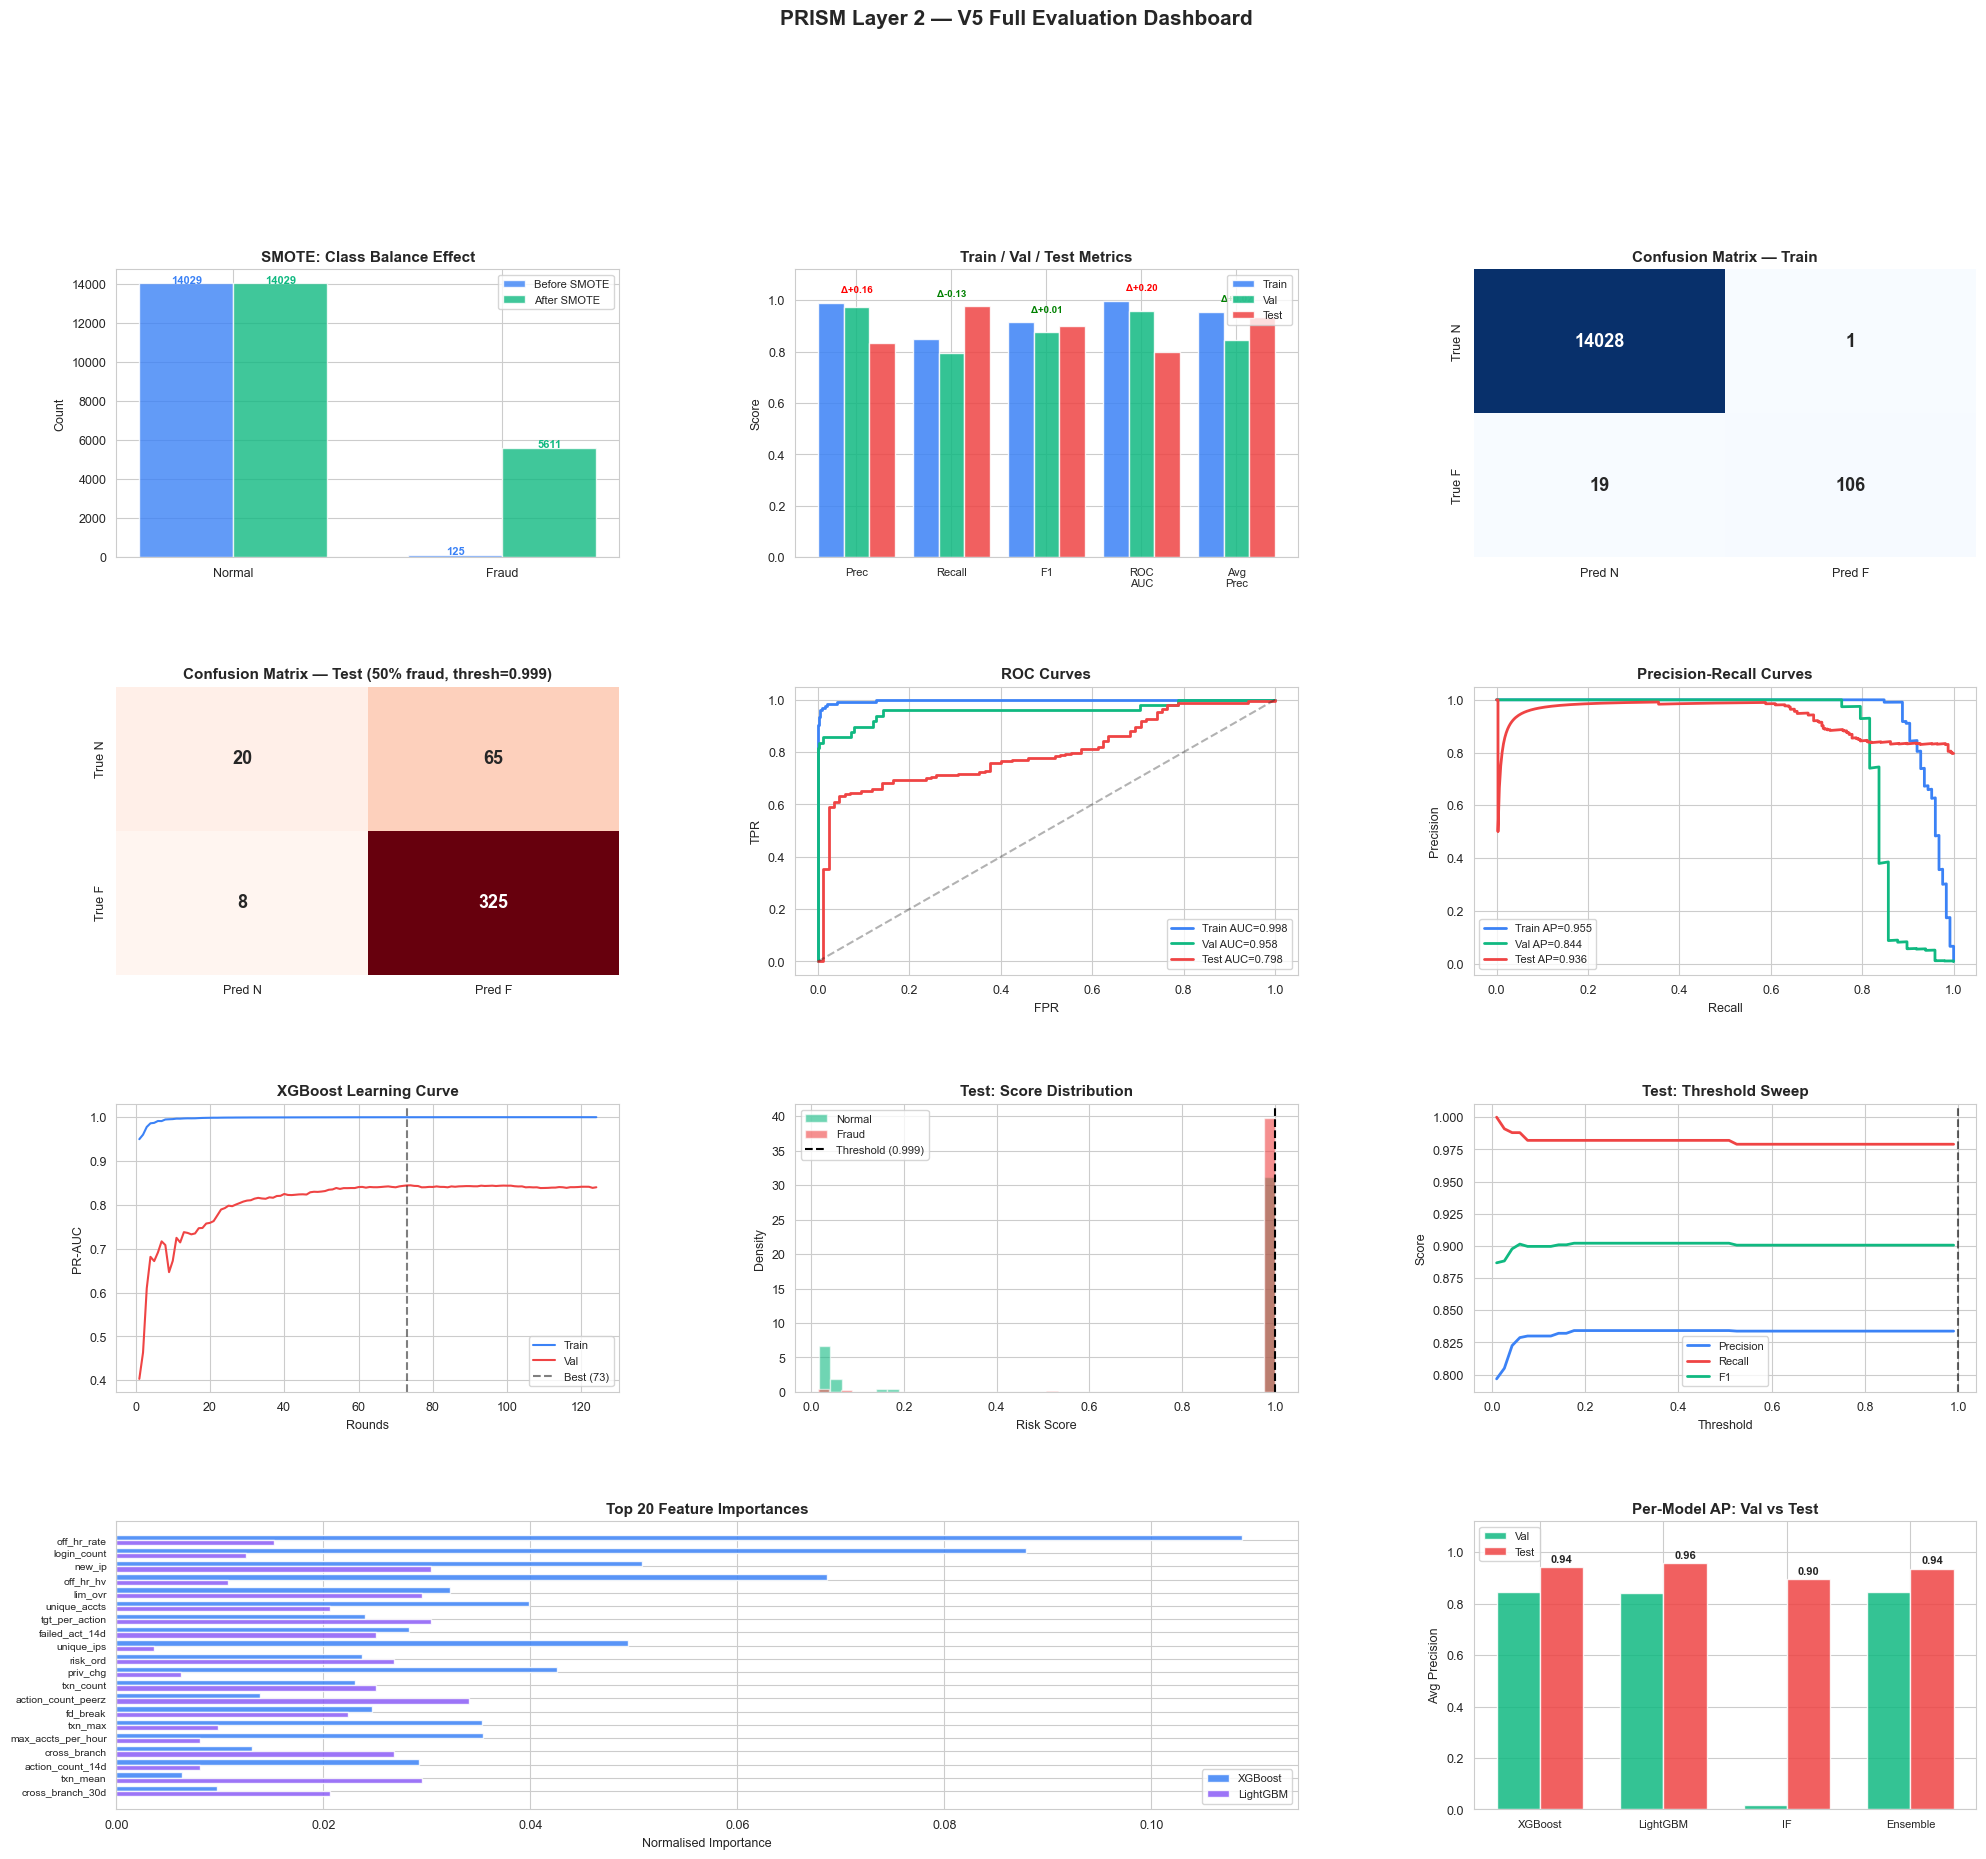


Plots saved to /Users/harsh/VS Code/PRISM/Layer_2/plots_v5/evaluation_v5.png


In [19]:
from sklearn.metrics import roc_curve

fig = plt.figure(figsize=(24, 20))
gs  = gridspec.GridSpec(4, 3, figure=fig, hspace=0.45, wspace=0.35)

BLUE, RED, GREEN, PURPLE, ORG = '#3b82f6','#ef4444','#10b981','#8b5cf6','#f59e0b'

# ── Panel 1: SMOTE class distribution before/after ─────────────────
ax = fig.add_subplot(gs[0, 0])
labels = ['Normal','Fraud']
pre  = [Counter(y_train)[0], Counter(y_train)[1]]
post = [Counter(y_train_sm)[0], Counter(y_train_sm)[1]]
x = np.arange(2); w = 0.35
ax.bar(x-w/2, pre,  w, label='Before SMOTE', color=BLUE, alpha=0.8)
ax.bar(x+w/2, post, w, label='After SMOTE',  color=GREEN, alpha=0.8)
ax.set_xticks(x); ax.set_xticklabels(labels)
ax.set_title('SMOTE: Class Balance Effect', fontweight='bold', fontsize=11)
ax.set_ylabel('Count'); ax.legend(fontsize=8)
for i,(a,b) in enumerate(zip(pre,post)):
    ax.annotate(f'{a}', (i-w/2, a+10), ha='center', fontsize=8, color=BLUE, fontweight='bold')
    ax.annotate(f'{b}', (i+w/2, b+10), ha='center', fontsize=8, color=GREEN, fontweight='bold')

# ── Panel 2: Train vs Val vs Test metric bars ───────────────────────
ax = fig.add_subplot(gs[0, 1])
mnames = ['precision','recall','f1','roc_auc','ap']
mlabels= ['Prec','Recall','F1','ROC\nAUC','Avg\nPrec']
tr_v = [Mtr_m[k] for k in mnames]
va_v = [Mva_m[k] for k in mnames]
te_v = [Mte_m[k] for k in mnames]
x = np.arange(len(mnames)); w=0.27
ax.bar(x-w,  tr_v, w, label='Train', color=BLUE,  alpha=0.85)
ax.bar(x,    va_v, w, label='Val',   color=GREEN, alpha=0.85)
ax.bar(x+w,  te_v, w, label='Test',  color=RED,   alpha=0.85)
ax.set_xticks(x); ax.set_xticklabels(mlabels, fontsize=8)
ax.set_ylim(0, 1.12); ax.set_ylabel('Score')
ax.set_title('Train / Val / Test Metrics', fontweight='bold', fontsize=11); ax.legend(fontsize=8)
for i,(tr,te) in enumerate(zip(tr_v,te_v)):
    gap=tr-te; c='red' if gap>OVERFIT_GAP else 'green'
    ax.annotate(f'Δ{gap:+.2f}', (i, max(tr,te)+0.04), ha='center', fontsize=7, color=c, fontweight='bold')

# ── Panel 3: Train confusion matrix ─────────────────────────────────
ax = fig.add_subplot(gs[0, 2])
sns.heatmap(cm_train, annot=True, fmt='d', cmap='Blues', cbar=False, ax=ax,
            xticklabels=['Pred N','Pred F'], yticklabels=['True N','True F'],
            annot_kws={'fontsize':13,'fontweight':'bold'})
ax.set_title('Confusion Matrix — Train', fontweight='bold', fontsize=11)

# ── Panel 4: Test confusion matrix ──────────────────────────────────
ax = fig.add_subplot(gs[1, 0])
sns.heatmap(cm_test, annot=True, fmt='d', cmap='Reds', cbar=False, ax=ax,
            xticklabels=['Pred N','Pred F'], yticklabels=['True N','True F'],
            annot_kws={'fontsize':13,'fontweight':'bold'})
ax.set_title(f'Confusion Matrix — Test (50% fraud, thresh={best_th:.3f})', fontweight='bold', fontsize=11)

# ── Panel 5: ROC Curves ─────────────────────────────────────────────
ax = fig.add_subplot(gs[1, 1])
for y,p,lbl,c in [(y_train,meta_train_p,'Train',BLUE),(y_val,meta_val_p,'Val',GREEN),(y_test,meta_test_p,'Test',RED)]:
    if y.sum()>0:
        fpr,tpr,_= roc_curve(y,p)
        auc=roc_auc_score(y,p)
        ax.plot(fpr,tpr,label=f'{lbl} AUC={auc:.3f}',linewidth=2,color=c)
ax.plot([0,1],[0,1],'k--',alpha=0.3); ax.set_xlabel('FPR'); ax.set_ylabel('TPR')
ax.set_title('ROC Curves', fontweight='bold', fontsize=11); ax.legend(fontsize=8)

# ── Panel 6: PR Curves ──────────────────────────────────────────────
ax = fig.add_subplot(gs[1, 2])
for y,p,lbl,c in [(y_train,meta_train_p,'Train',BLUE),(y_val,meta_val_p,'Val',GREEN),(y_test,meta_test_p,'Test',RED)]:
    if y.sum()>0:
        pr,re,_=precision_recall_curve(y,p)
        ap=average_precision_score(y,p)
        ax.plot(re,pr,label=f'{lbl} AP={ap:.3f}',linewidth=2,color=c)
ax.set_xlabel('Recall'); ax.set_ylabel('Precision')
ax.set_title('Precision-Recall Curves', fontweight='bold', fontsize=11); ax.legend(fontsize=8)

# ── Panel 7: XGBoost learning curve ─────────────────────────────────
ax = fig.add_subplot(gs[2, 0])
if xgb_hist:
    ep = range(1, len(xgb_hist['train'])+1)
    ax.plot(ep, xgb_hist['train'], label='Train', color=BLUE, linewidth=1.5)
    ax.plot(ep, xgb_hist['val'],   label='Val',   color=RED,  linewidth=1.5)
    if hasattr(xgb_model,'best_iteration'):
        ax.axvline(xgb_model.best_iteration, color='black', linestyle='--', alpha=0.5,
                   label=f'Best ({xgb_model.best_iteration})')
    ax.set_xlabel('Rounds'); ax.set_ylabel('PR-AUC')
    ax.set_title('XGBoost Learning Curve', fontweight='bold', fontsize=11); ax.legend(fontsize=8)

# ── Panel 8: Score distributions on test ────────────────────────────
ax = fig.add_subplot(gs[2, 1])
ax.hist(meta_test_p[y_test==0], bins=40, alpha=0.6, label='Normal', color=GREEN, density=True)
ax.hist(meta_test_p[y_test==1], bins=40, alpha=0.6, label='Fraud',  color=RED,  density=True)
ax.axvline(best_th, color='black', linestyle='--', linewidth=1.5, label=f'Threshold ({best_th:.3f})')
ax.set_xlabel('Risk Score'); ax.set_ylabel('Density')
ax.set_title('Test: Score Distribution', fontweight='bold', fontsize=11); ax.legend(fontsize=8)

# ── Panel 9: Threshold sweep on test ────────────────────────────────
ax = fig.add_subplot(gs[2, 2])
ths_sw = np.linspace(0.01,0.99,60)
ps_sw,rs_sw,fs_sw=[],[],[]
for th in ths_sw:
    yp=(meta_test_p>=th).astype(int)
    ps_sw.append(precision_score(y_test,yp,zero_division=0))
    rs_sw.append(recall_score(y_test,yp,zero_division=0))
    fs_sw.append(f1_score(y_test,yp,zero_division=0))
ax.plot(ths_sw,ps_sw,label='Precision',linewidth=2,color=BLUE)
ax.plot(ths_sw,rs_sw,label='Recall',   linewidth=2,color=RED)
ax.plot(ths_sw,fs_sw,label='F1',       linewidth=2,color=GREEN)
ax.axvline(best_th, color='black', linestyle='--', alpha=0.6)
ax.set_xlabel('Threshold'); ax.set_ylabel('Score')
ax.set_title('Test: Threshold Sweep', fontweight='bold', fontsize=11); ax.legend(fontsize=8)

# ── Panel 10: Feature importance ────────────────────────────────────
ax = fig.add_subplot(gs[3, 0:2])
fi = pd.DataFrame({'feature': FEATURE_COLS,
                    'xgb': xgb_model.feature_importances_ / max(xgb_model.feature_importances_.sum(),1e-9),
                    'lgb': lgb_model.feature_importances_ / max(lgb_model.feature_importances_.sum(),1e-9)})
fi['avg'] = (fi['xgb']+fi['lgb'])/2
top20 = fi.nlargest(20,'avg')
ypos = np.arange(len(top20))
ax.barh(ypos-0.2, top20['xgb'].values, 0.4, label='XGBoost',  color=BLUE,   alpha=0.85)
ax.barh(ypos+0.2, top20['lgb'].values, 0.4, label='LightGBM', color=PURPLE, alpha=0.85)
ax.set_yticks(ypos); ax.set_yticklabels(top20['feature'], fontsize=7.5)
ax.invert_yaxis(); ax.set_xlabel('Normalised Importance')
ax.set_title('Top 20 Feature Importances', fontweight='bold', fontsize=11); ax.legend(fontsize=8)

# ── Panel 11: Per-model AP comparison ───────────────────────────────
ax = fig.add_subplot(gs[3, 2])
models  = ['XGBoost','LightGBM','IF','Ensemble']
if_norm = (if_test - if_test.min())/(if_test.max()-if_test.min()+1e-9)
aps_te  = [average_precision_score(y_test,xgb_test_p),
           average_precision_score(y_test,lgb_test_p),
           average_precision_score(y_test,if_norm),
           Mte_m['ap']]
aps_va  = [average_precision_score(y_val,xgb_val_p),
           average_precision_score(y_val,lgb_val_p),
           average_precision_score(y_val,-iforest.decision_function(scaler.transform(X_val))),
           Mva_m['ap']]
x=np.arange(len(models)); w=0.35
ax.bar(x-w/2, aps_va, w, label='Val',  color=GREEN, alpha=0.85)
ax.bar(x+w/2, aps_te, w, label='Test', color=RED,   alpha=0.85)
ax.set_xticks(x); ax.set_xticklabels(models, fontsize=8)
ax.set_ylim(0,1.12); ax.set_ylabel('Avg Precision'); ax.legend(fontsize=8)
ax.set_title('Per-Model AP: Val vs Test', fontweight='bold', fontsize=11)
for i,(v,t) in enumerate(zip(aps_va,aps_te)):
    ax.annotate(f'{t:.2f}',(i+w/2,t+0.02),ha='center',fontsize=8,fontweight='bold')

plt.suptitle('PRISM Layer 2 — V5 Full Evaluation Dashboard',
             fontsize=15, fontweight='bold', y=1.01)
plt.savefig(f'{PLOTS_DIR}/evaluation_v5.png', dpi=120, bbox_inches='tight')
plt.show()
print(f'\nPlots saved to {PLOTS_DIR}/evaluation_v5.png')

## Step 12: SHAP Causal Chains on Test Set Alerts

In [20]:
SHAP_CP = 'shap_test_v5.npy'
NARR_CP = 'narratives_test_v5.parquet'

anom_idx = np.where(test_pred==1)[0]
X_anom   = X_test.iloc[anom_idx]
print(f'{len(anom_idx)} alerts on test set')

if len(anom_idx) == 0:
    print('No anomalies flagged — try lowering the threshold.')
else:
    if cpe(SHAP_CP) and cpe(NARR_CP):
        shap_vals  = cpl(SHAP_CP)
        narratives = cpl(NARR_CP)
    else:
        explainer  = shap.TreeExplainer(xgb_model)
        shap_vals  = explainer.shap_values(X_anom)
        cps(shap_vals, SHAP_CP)

        STORY = {
            'off_hr_txn':     '{val:.0f} off-hours transactions',
            'off_hr_act':     '{val:.0f} off-hours system actions',
            'fd_break':       '{val:.0f} FD premature breaks',
            'fd_brk_act':     '{val:.0f} FD break actions',
            'lim_ovr':        '{val:.0f} limit overrides (txn)',
            'lim_ovr_act':    '{val:.0f} limit override actions',
            'to_dep':         '{val:.0f} transfers to dependent account',
            'to_emp':         '{val:.0f} transfers to employee accounts',
            'off_hr_hv':      '{val:.0f} off-hours high-value transactions',
            'off_hr_login':   '{val:.0f} off-hours logins',
            'failed_login':   '{val:.0f} failed login attempts',
            'priv_chg':       '{val:.0f} privilege/config changes',
            'cross_branch':   '{val:.0f} cross-branch accesses',
            'new_ip':         '{val:.0f} logins from new IP addresses',
            'max_accts_per_hour': 'Peak of {val:.0f} accounts in 1 hour',
            'data_exp_act':   '{val:.0f} data export actions',
            'file_dl':        '{val:.0f} file downloads',
            'cust_mod':       '{val:.0f} customer record modifications',
            'txn_count_selfz':'Txn volume {val:.1f}σ above own baseline',
            'txn_total_selfz':'Total amount {val:.1f}σ above own baseline',
            'action_count_selfz':'Activity {val:.1f}σ above own baseline',
            'unique_targets_peerz':'{val:.1f}σ more unique accounts than peers',
            'burst_score':    'Account burst score: {val:.1f} per login',
            'fail_login_rate':'Failed login rate: {val:.0%}',
            'off_hr_x_exp':   'Off-hours × export combo ({val:.0f})',
            'fd_x_dep':       'FD break × dependent transfer ({val:.0f})',
        }

        test_meta = fm_test[['employee_id','date']].reset_index(drop=True)
        rows = []
        for i, idx in enumerate(anom_idx):
            emp_id = test_meta.iloc[idx]['employee_id']
            d      = test_meta.iloc[idx]['date']
            proba  = float(meta_test_p[idx])
            is_f   = int(y_test[idx])
            sv     = shap_vals[i]; raw = X_anom.iloc[i].values
            contribs = sorted(zip(FEATURE_COLS,sv,raw), key=lambda x:-x[1])
            parts = []
            for fn,s,rv in contribs[:8]:
                if s<0.005 or rv==0: continue
                if fn in STORY: parts.append(STORY[fn].format(val=rv))
                if len(parts)>=5: break
            rows.append({'employee_id':emp_id,'date':d,'risk_proba':proba,
                          'is_fraud':is_f,
                          'causal_chain':f'{emp_id} | {pd.Timestamp(d).date()}: '+(' → '.join(parts) if parts else 'anomaly')})
        narratives = pd.DataFrame(rows)
        cps(narratives, NARR_CP)

    print(f'\n{"Status":<8} {"Risk":>6}  Causal Chain')
    print('='*120)
    for _,r in narratives.nlargest(15,'risk_proba').iterrows():
        lbl = 'FRAUD ✓' if r['is_fraud'] else 'NORMAL '
        print(f'[{lbl}] {r["risk_proba"]:.3f}  {r["causal_chain"]}')

390 alerts on test set

Status     Risk  Causal Chain
[FRAUD ✓] 1.000  TEST_EMP_00015 | 2026-04-02: 1 logins from new IP addresses → Account burst score: 1.0 per login → -0.0σ more unique accounts than peers
[NORMAL ] 1.000  TEST_EMP_00001 | 2026-04-03: 1 logins from new IP addresses → Account burst score: 1.0 per login → -0.2σ more unique accounts than peers
[FRAUD ✓] 1.000  TEST_EMP_00010 | 2026-04-04: 3 logins from new IP addresses → Account burst score: 2.0 per login → Activity 5.8σ above own baseline
[FRAUD ✓] 1.000  TEST_EMP_00002 | 2026-04-03: 3 logins from new IP addresses → Account burst score: 2.0 per login → 1 off-hours logins
[FRAUD ✓] 1.000  TEST_EMP_00012 | 2026-04-03: 1 limit overrides (txn) → 1 logins from new IP addresses → Account burst score: 1.0 per login
[FRAUD ✓] 1.000  TEST_EMP_00015 | 2026-04-03: 1 off-hours transactions → 1 FD premature breaks → Account burst score: 1.0 per login
[FRAUD ✓] 1.000  TEST_EMP_00002 | 2026-04-02: 1 logins from new IP addresses → Acc

## Step 13: Save Production Bundle

In [21]:
BUNDLE = os.path.join(MODEL_DIR, 'layer2_v5_bundle.joblib')

bundle = {
    'version': '5.0',
    'algorithm': 'XGBoost+LightGBM+IF Stacking | SMOTE | Leakage-Free',
    'feature_cols': FEATURE_COLS,
    'xgb_model':   xgb_model,
    'lgb_model':   lgb_model,
    'iforest':     iforest,
    'scaler':      scaler,
    'meta_model':  meta,
    'threshold':   best_th,
    'hv_thresh':   float(hv_thresh),
    'peer_stats':  peer_stats,
    'train_metrics': Mtr_m,
    'val_metrics':   Mva_m,
    'test_metrics':  Mte_m,
    'rolling_windows': ROLLING_WINDOWS,
}
joblib.dump(bundle, BUNDLE)
print(f'Bundle saved: {os.path.getsize(BUNDLE)/1024/1024:.1f} MB')
print(f'Path: {BUNDLE}')

Bundle saved: 2.8 MB
Path: /Users/harsh/VS Code/PRISM/Layer_2/models_v5/layer2_v5_bundle.joblib


## Reset (Optional)

In [22]:
# Wipe V5 checkpoints to force full retraining:
# import shutil
# shutil.rmtree(CHECKPOINT_DIR, ignore_errors=True)
# os.makedirs(CHECKPOINT_DIR, exist_ok=True)
print('Uncomment above to reset.')

Uncomment above to reset.


## Summary

| Step | What Changed vs V4 | Why |
|------|-------------------|-----|
| Data loading | Separate TRAIN_DIR and TEST_DIR from Drive | Mirrors your Drive folder structure |
| Feature engineering | Shared `build_features()` — reuses `hv_thresh` and `peer_stats` from train on test | Prevents distribution shift |
| SMOTE | Applied ONLY to training split (not val/test) | Fixes 0.86% fraud imbalance without leaking |
| XGBoost / LGB | Tuned on SMOTE-balanced data, early stopping on **original** val set | Models see balanced training but are evaluated on real distribution |
| Threshold | Optimised on val set (original imbalance), applied to test | Realistic operating point |
| Plots | 12-panel: SMOTE effect, train/val/test metrics, dual confusion matrices, ROC, PR, learning curves, score distribution, threshold sweep, feature importance, per-model comparison | Comprehensive honest evaluation |
| Test evaluation | Inference on 50% fraud dataset (new employees) | Out-of-sample generalisation check |